# Класифікація котів та собак за допомогою машинного навчання

**Мета роботи:** виконати повний цикл задачі бінарної класифікації зображень, де модель повинна визначати, хто зображений на фото: кіт чи собака. Для цього послідовно виконуються завантаження та очищення даних, експлораторний аналіз, підготовка генераторів, побудова двох моделей, оцінка якості та тестування на власному зображенні.

Ця задача є задачею **бінарної класифікації**, тому що існує лише два можливі класи: Cat і Dog. Для такого типу задачі доречно використовувати сигмоїдну функцію активації на виході моделі, втрату binary_crossentropy, а також метрики accuracy, precision, recall та F1-score.

У роботі порівнюються два підходи. Перший підхід — проста CNN, яка навчається з нуля тільки на наданому датасеті. Другий підхід: MobileNetV2 з transfer learning, тобто модель, яка вже була попередньо навчена на великій кількості зображень і може використовувати готові візуальні ознаки. Очікується, що MobileNetV2 покаже кращий результат, оскільки для задач комп'ютерного зору попередньо навчені моделі часто працюють стабільніше, особливо коли кількість епох навчання обмежена.


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from google.colab import files

SEED = 42
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 5

tf.random.set_seed(SEED)
np.random.seed(SEED)


## 1. Завантаження та очищення даних

Для роботи використовується датасет **Microsoft Cats vs Dogs**, який містить зображення котів і собак у двох окремих папках. Перед аналізом і навчанням моделі дані потрібно перевірити, тому що у реальних датасетах часто трапляються пошкоджені або некоректні файли.

Очищення даних виконується за допомогою cv2.imread(). Якщо зображення не відкривається або має порожній вміст, воно видаляється з датасету. Це важливий етап, оскільки пошкоджені файли можуть викликати помилки під час роботи генератора зображень або перервати процес навчання моделі.

Після очищення виводиться кількість видалених файлів. Це також можна вважати частиною виявлення аномалій, адже такі файли не відповідають очікуваному формату даних.


In [ ]:
!wget --no-check-certificate https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip -O data.zip
!unzip -q data.zip

data_dir = 'PetImages'
classes = ['Cat', 'Dog']

def clean_images(path):
    deleted = 0
    for category in classes:
        folder = os.path.join(path, category)
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            try:
                img = cv2.imread(img_path)
                if img is None or img.size == 0:
                    os.remove(img_path)
                    deleted += 1
            except Exception:
                os.remove(img_path)
                deleted += 1
    return deleted

deleted_files = clean_images(data_dir)
print(f'Видалено пошкоджених файлів: {deleted_files}')


--2026-05-05 09:14:32--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.207.193.216, 2600:1413:5000:482::317f, 2600:1413:5000:489::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.207.193.216|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘data.zip’

data.zip            100%[===================>] 786.67M  99.6MB/s    in 13s     

2026-05-05 09:14:45 (61.5 MB/s) - ‘data.zip’ saved [824887076/824887076]

Видалено пошкоджених файлів: 5


## 2. Експлораторний аналіз даних (EDA)

Експлораторний аналіз даних потрібен для того, щоб краще зрозуміти структуру датасету до побудови моделей. На цьому етапі перевіряється кількість зображень у кожному класі, можливий дисбаланс класів, розміри зображень та наявність потенційних аномалій.

Для задачі класифікації дуже важливо знати, чи приблизно однакова кількість об'єктів у кожному класі. Якщо один клас значно переважає інший, модель може навчитися частіше передбачати саме більший клас і при цьому мати формально непогану accuracy. Тому додатково аналізуються precision, recall і F1-score.

Також перевіряються розміри зображень. У датасеті вони можуть бути різними, але нейронна мережа потребує однакового розміру вхідних даних. Саме тому перед подачею в модель усі зображення приводяться до розміру **128×128**.


In [ ]:
class_counts = {category: len(os.listdir(os.path.join(data_dir, category))) for category in classes}
class_df = pd.DataFrame({
    'class': list(class_counts.keys()),
    'count': list(class_counts.values())
})
class_df['percent'] = class_df['count'] / class_df['count'].sum() * 100
class_df


,class,count,percent
0,Cat,12498,49.998
1,Dog,12499,50.002


### Пояснення таблиці класів

Таблиця показує кількість зображень у кожному класі та їхню частку у відсотках. Це перший крок для перевірки балансу датасету.

Для задачі коти/собаки бажано, щоб обидва класи були представлені приблизно однаково. Тоді модель отримує достатньо прикладів кожного класу і має менший ризик навчитися віддавати перевагу лише одному з них.


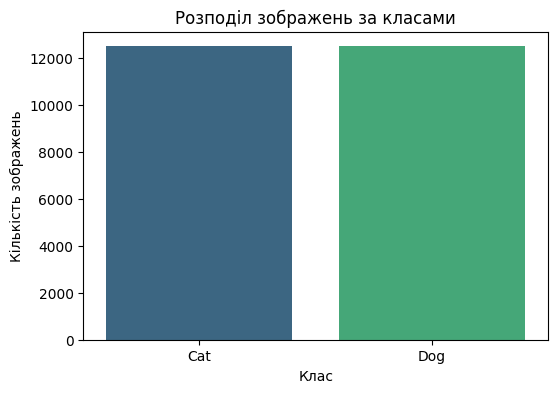

Коефіцієнт дисбалансу класів: 1.000
Висновок: сильного дисбалансу класів немає.


In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=class_df, x='class', y='count', hue='class', palette='viridis', legend=False)
plt.title('Розподіл зображень за класами')
plt.xlabel('Клас')
plt.ylabel('Кількість зображень')
plt.show()

imbalance_ratio = class_df['count'].max() / class_df['count'].min()
print(f'Коефіцієнт дисбалансу класів: {imbalance_ratio:.3f}')

if imbalance_ratio < 1.2:
    print('Висновок: сильного дисбалансу класів немає.')
else:
    print('Висновок: є помітний дисбаланс, тому варто враховувати F1, precision та recall.')


### Інтерпретація дисбалансу класів

Коефіцієнт дисбалансу показує, у скільки разів більший клас перевищує менший. Якщо значення близьке до 1, класи збалансовані. Якщо значення значно більше, модель може зміщуватися в бік класу, який частіше трапляється у навчальних даних.

У випадку дисбалансу accuracy може бути оманливою. Наприклад, якщо один клас становить більшість, модель може часто передбачати саме його і отримувати високу accuracy, але погано розпізнавати менший клас. Тому в роботі додатково використовуються precision, recall і F1-score.


In [ ]:
image_info = []

for category in classes:
    folder = os.path.join(data_dir, category)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            h, w = img.shape[:2]
            image_info.append({
                'class': category,
                'filename': img_name,
                'width': w,
                'height': h,
                'area': w * h
            })

image_df = pd.DataFrame(image_info)
image_df[['width', 'height', 'area']].describe()


,width,height,area
count,24997.000000,24997.000000,24997.000000
mean,404.507261,360.927991,151512.476537
std,108.967147,97.019071,59262.979920
min,4.000000,4.000000,16.000000
25%,323.000000,301.000000,106400.000000
50%,448.000000,375.000000,175500.000000
75%,500.000000,421.000000,187500.000000
max,500.000000,500.000000,250000.000000


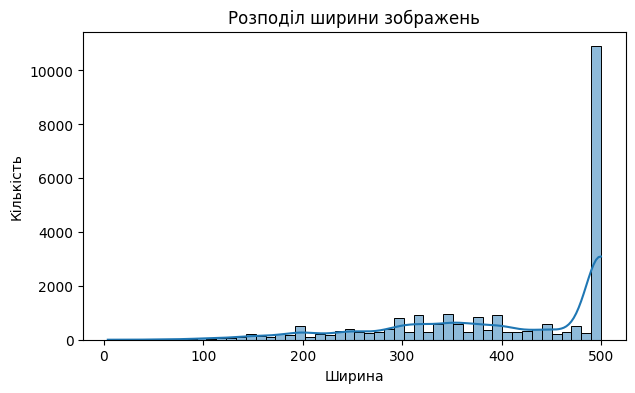

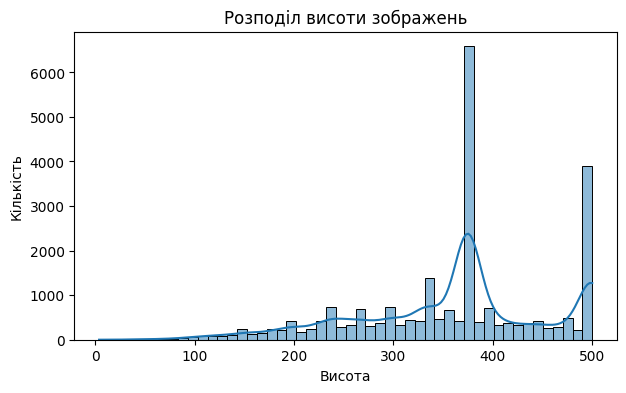

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(image_df['width'], bins=50, kde=True)
plt.title('Розподіл ширини зображень')
plt.xlabel('Ширина')
plt.ylabel('Кількість')
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(image_df['height'], bins=50, kde=True)
plt.title('Розподіл висоти зображень')
plt.xlabel('Висота')
plt.ylabel('Кількість')
plt.show()


### Інтерпретація розподілу розмірів

Гістограми ширини та висоти показують, які розміри зображень найчастіше зустрічаються у датасеті. Якщо розподіл дуже широкий, це означає, що зображення мають різну якість і різний масштаб.

Нейронна мережа не може напряму працювати з батчем зображень різних розмірів, тому всі файли приводяться до однакового формату. У цій роботі використовується 128×128, що є компромісом між швидкістю навчання і збереженням корисної інформації.


In [ ]:
q1 = image_df['area'].quantile(0.25)
q3 = image_df['area'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

anomalies = image_df[(image_df['area'] < lower_bound) | (image_df['area'] > upper_bound)]
print(f'Кількість потенційних аномалій за площею зображення: {len(anomalies)}')
anomalies.head(10)


Кількість потенційних аномалій за площею зображення: 0


,class,filename,width,height,area


### Пояснення пошуку аномалій

Для пошуку потенційних аномалій використовується площа зображення, тобто добуток ширини на висоту. Межі аномальних значень визначаються за правилом IQR: усе, що значно менше або більше за типовий діапазон, вважається потенційною аномалією.

Такі зображення не видаляються автоматично, тому що великий або малий розмір не завжди означає помилку. Але їх потрібно враховувати під час аналізу, адже вони можуть бути нетиповими для датасету.


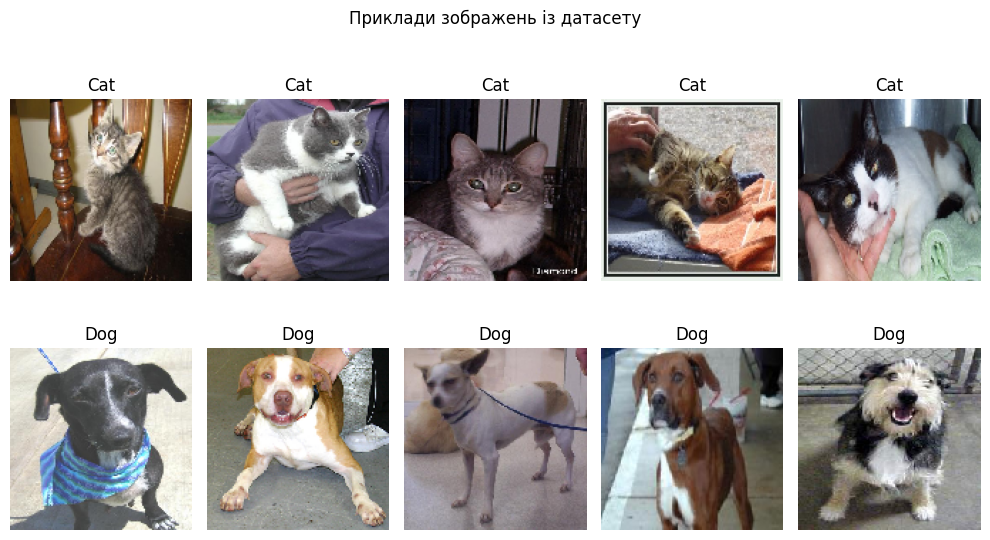

In [ ]:
plt.figure(figsize=(10, 6))
for i, category in enumerate(classes):
    folder = os.path.join(data_dir, category)
    sample_files = os.listdir(folder)[:5]
    for j, img_name in enumerate(sample_files):
        img_path = os.path.join(folder, img_name)
        img = image.load_img(img_path, target_size=IMG_SIZE)
        plt.subplot(2, 5, i * 5 + j + 1)
        plt.imshow(img)
        plt.title(category)
        plt.axis('off')
plt.suptitle('Приклади зображень із датасету')
plt.tight_layout()
plt.show()


### Висновки після EDA

Після аналізу кількості зображень можна оцінити, чи є у датасеті дисбаланс класів. Якщо коефіцієнт дисбалансу близький до 1, це означає, що котів і собак приблизно однакова кількість, тому модель не має сильної початкової переваги в бік одного класу. Якщо ж коефіцієнт помітно більший, тоді під час оцінки якості потрібно особливо уважно дивитися не лише на accuracy, а й на precision, recall та F1-score.

Описова статистика ширини, висоти та площі зображень показує, наскільки різними є файли в датасеті. Оскільки зображення мають різні розміри, їх необхідно привести до єдиного формату перед навчанням. Тут використовується розмір 128×128, що дозволяє зменшити обчислювальне навантаження і водночас зберегти достатньо інформації для розпізнавання тварин.

Аномалії за площею зображення визначаються через міжквартильний розмах. Такі зображення не обов'язково є помилковими, але вони можуть суттєво відрізнятися від більшості даних. Їх варто переглядати окремо, тому що надто маленькі, надто великі або нестандартні зображення іноді погіршують навчання моделі.

Перегляд прикладів зображень допомагає візуально переконатися, що дані відповідають задачі: у папці Cat справді знаходяться коти, а в папці Dog — собаки. Це простий, але важливий крок, бо неправильне маркування даних може негативно вплинути на результат навіть при хорошій архітектурі моделі.


## 3. Підготовка генераторів даних

Для подачі зображень у модель використовуються генератори ImageDataGenerator. Вони автоматично зчитують зображення з папок, змінюють їхній розмір, нормалізують пікселі та формують батчі для навчання.

Для тренувальної вибірки використовується аугментація: невеликі повороти, масштабування, зміщення та горизонтальне відображення. Це потрібно для того, щоб модель не запам'ятовувала конкретні зображення, а краще навчалася розпізнавати загальні ознаки котів і собак. Завдяки аугментації модель бачить трохи змінені варіанти зображень і стає стійкішою до різних положень об'єкта на фото.

Для валідаційної вибірки використовується тільки нормалізація, без випадкових перетворень. Це правильно, тому що валідаційні дані мають показувати реальну якість моделі на незмінених прикладах. Також для val_gen встановлено shuffle=False. Це важливо для коректної побудови confusion matrix, тому що порядок справжніх класів має відповідати порядку прогнозів моделі.


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print(train_gen.class_indices)


Found 19999 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
{'Cat': 0, 'Dog': 1}


### Пояснення поділу даних

Параметр validation_split=0.2 означає, що 20% даних використовується для валідації, а решта 80% для навчання. Навчальна вибірка потрібна для оновлення ваг моделі, а валідаційна для перевірки якості на даних, які модель не використовує безпосередньо для навчання.

Такий поділ дозволяє оцінити, наскільки добре модель буде працювати на нових зображеннях. Це важливіше, ніж просто отримати високу якість на тренувальних даних.


## 4. Побудова моделей

Для виконання вимоги порівняння мінімум двох алгоритмів у роботі побудовано дві різні моделі.

Перша модель: **Simple CNN**. Вона складається з кількох згорткових шарів Conv2D, шарів зменшення розмірності MaxPooling2D, повнозв'язного шару Dense та Dropout. Ця модель навчається з нуля, тобто всі ознаки вона повинна самостійно вивчити з навчального датасету. Її перевага в простоті та зрозумілості структури, але недолік у тому, що для хорошої якості їй може знадобитися більше даних і більше епох навчання.

Друга модель: **MobileNetV2** з transfer learning. У ній використовується готова згорткова основа, попередньо навчена на ImageNet. Ця основа вже вміє виділяти базові ознаки зображень: краї, текстури, форми та складніші візуальні патерни. Тут базова частина MobileNetV2 заморожується, а навчаються лише верхні шари класифікатора. Такий підхід дозволяє швидше отримати якісний результат і зменшує ризик перенавчання.

Порівняння цих моделей дозволяє побачити різницю між навчанням з нуля і використанням попередньо навченої архітектури.


In [ ]:
def build_simple_cnn():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

simple_cnn = build_simple_cnn()
simple_cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_cnn = simple_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


Epoch 1/5
312/625 ━━━━━━━━━━━━━━━━━━━━ 57s 185ms/step - accuracy: 0.5269 - loss: 0.7071

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 198ms/step - accuracy: 0.5944 - loss: 0.6671 - val_accuracy: 0.6737 - val_loss: 0.6145
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 182ms/step - accuracy: 0.7044 - loss: 0.5681 - val_accuracy: 0.7575 - val_loss: 0.4887
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 116s 186ms/step - accuracy: 0.7530 - loss: 0.5042 - val_accuracy: 0.8027 - val_loss: 0.4326
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 183ms/step - accuracy: 0.7840 - loss: 0.4643 - val_accuracy: 0.7805 - val_loss: 0.4778
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 116s 186ms/step - accuracy: 0.8003 - loss: 0.4370 - val_accuracy: 0.8137 - val_loss: 0.4109


### Пояснення навчання Simple CNN

Simple CNN є базовою моделлю для порівняння. Вона поступово виділяє ознаки зображення: перші згорткові шари можуть знаходити прості патерни, наприклад краї або контури, а глибші шари — складніші форми.

У моделі використовується Dropout, щоб зменшити ризик перенавчання. Також застосовується EarlyStopping, який зупиняє навчання, якщо якість на валідаційній вибірці перестає покращуватися. Це допомагає уникнути ситуації, коли модель продовжує запам'ятовувати навчальні дані, але не покращує результат на нових прикладах.


In [ ]:
base_model = applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

mobilenet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [ ]:
history_mobilenet = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 159s 226ms/step - accuracy: 0.9381 - loss: 0.1519 - val_accuracy: 0.9504 - val_loss: 0.1297
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 180ms/step - accuracy: 0.9515 - loss: 0.1227 - val_accuracy: 0.9654 - val_loss: 0.0899
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 115s 184ms/step - accuracy: 0.9515 - loss: 0.1206 - val_accuracy: 0.9568 - val_loss: 0.1125
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 182ms/step - accuracy: 0.9534 - loss: 0.1170 - val_accuracy: 0.9650 - val_loss: 0.0897
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 181ms/step - accuracy: 0.9553 - loss: 0.1086 - val_accuracy: 0.9630 - val_loss: 0.0918


### Пояснення вибору MobileNetV2

MobileNetV2 є ефективною архітектурою для класифікації зображень. У цій роботі вона використовується не повністю з нуля, а як попередньо навчена модель. Це означає, що її базові шари вже мають знання про загальні візуальні ознаки, отримані під час навчання на великому датасеті ImageNet.

Замороження base_model.trainable = False означає, що ваги базової частини не змінюються під час навчання. Навчаються тільки додані зверху шари, які адаптують готові ознаки до конкретної задачі: розрізнення котів і собак. Це робить навчання швидшим і стабільнішим.


## 5. Оцінка якості моделей

Оскільки задача є бінарною класифікацією, для оцінки використовуються кілька метрик. **Accuracy** показує загальну частку правильних прогнозів. Проте однієї accuracy недостатньо, особливо якщо у даних є дисбаланс класів або модель частіше помиляється на одному з класів.

**Precision** показує, наскільки точними є позитивні прогнози моделі. У цій задачі позитивним класом є Dog, оскільки генератор кодує класи числовими мітками. **Recall** показує, яку частину справжніх собак модель змогла знайти. **F1-score** поєднує precision і recall в одну метрику, тому вона зручна для загального порівняння моделей.

Також використовується **confusion matrix**. Вона показує не лише загальну кількість помилок, а й те, які саме помилки робить модель: котів плутає із собаками чи собак — із котами. Це дає більш детальне розуміння якості класифікації.


In [ ]:
def evaluate_model(model, generator, model_name):
    generator.reset()
    y_true = generator.classes
    y_prob = model.predict(generator).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'y_true': y_true,
        'y_pred': y_pred
    }

cnn_results = evaluate_model(simple_cnn, val_gen, 'Simple CNN')
mobilenet_results = evaluate_model(mobilenet_model, val_gen, 'MobileNetV2')

metrics_df = pd.DataFrame([
    {k: v for k, v in cnn_results.items() if k not in ['y_true', 'y_pred']},
    {k: v for k, v in mobilenet_results.items() if k not in ['y_true', 'y_pred']}
])
metrics_df


157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step


,model,accuracy,precision,recall,f1
0,Simple CNN,0.813725,0.783237,0.867547,0.823239
1,MobileNetV2,0.964986,0.958926,0.971589,0.965216


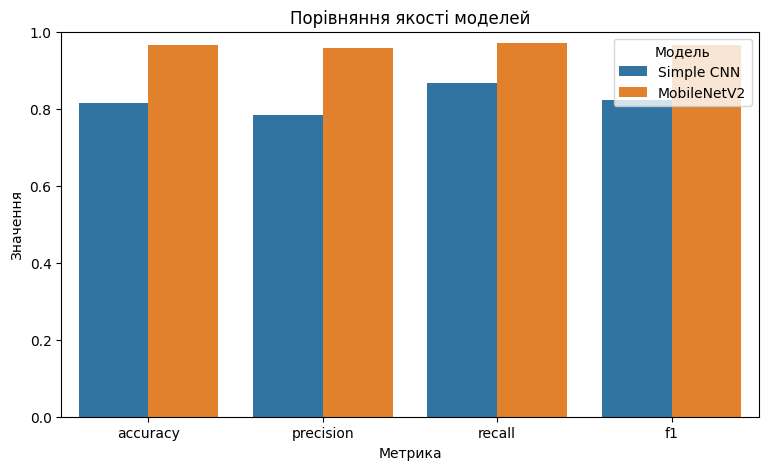

In [ ]:
metrics_plot_df = metrics_df.melt(id_vars='model', var_name='metric', value_name='value')

plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_plot_df, x='metric', y='value', hue='model')
plt.ylim(0, 1)
plt.title('Порівняння якості моделей')
plt.xlabel('Метрика')
plt.ylabel('Значення')
plt.legend(title='Модель')
plt.show()


### Інтерпретація порівняння метрик

Таблиця та графік метрик дають змогу напряму порівняти Simple CNN і MobileNetV2. Якщо одна модель має вищі значення за всіма або більшістю метрик, її можна вважати кращою для цієї задачі.

Особливу увагу варто звернути на F1-score. Ця метрика є корисною тоді, коли потрібно врахувати і точність позитивних прогнозів, і здатність моделі знаходити позитивний клас. Саме тому фінальна модель обирається за F1-score, а не лише за accuracy.


In [ ]:
best_results = mobilenet_results if mobilenet_results['f1'] >= cnn_results['f1'] else cnn_results
best_model = mobilenet_model if best_results['model'] == 'MobileNetV2' else simple_cnn

print(f"Краща модель за F1-score: {best_results['model']}")
print(classification_report(
    best_results['y_true'],
    best_results['y_pred'],
    target_names=['Cat', 'Dog'],
    zero_division=0
))


Краща модель за F1-score: MobileNetV2
              precision    recall  f1-score   support

         Cat       0.97      0.96      0.96      2499
         Dog       0.96      0.97      0.97      2499

    accuracy                           0.96      4998
   macro avg       0.97      0.96      0.96      4998
weighted avg       0.97      0.96      0.96      4998



### Інтерпретація classification report

У classification report окремо показано precision, recall і F1-score для кожного класу. Це дозволяє оцінити, чи модель однаково добре працює і для котів, і для собак.

Якщо для одного класу recall нижчий, це означає, що модель часто не розпізнає цей клас. Якщо precision нижчий, це означає, що модель часто помилково відносить інші зображення до цього класу. Найкращою є ситуація, коли precision, recall і F1-score високі та приблизно збалансовані для обох класів.


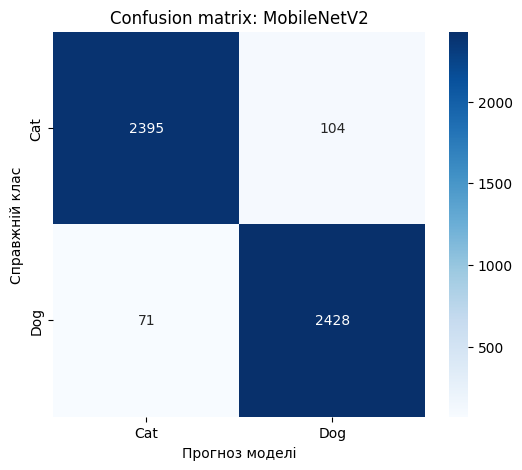

In [ ]:
cm = confusion_matrix(best_results['y_true'], best_results['y_pred'])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cat', 'Dog'],
    yticklabels=['Cat', 'Dog']
)
plt.title(f"Confusion matrix: {best_results['model']}")
plt.xlabel('Прогноз моделі')
plt.ylabel('Справжній клас')
plt.show()


### Інтерпретація confusion matrix

У confusion matrix рядки відповідають справжнім класам, а стовпці прогнозам моделі. Значення на головній діагоналі показують правильні передбачення, а значення поза діагоналлю — помилки.

Якщо у верхньому правому куті велике значення, це означає, що модель часто класифікує котів як собак. Якщо велике значення у нижньому лівому куті, модель часто класифікує собак як котів. Такий аналіз корисний, бо він показує не просто кількість помилок, а їхній тип.


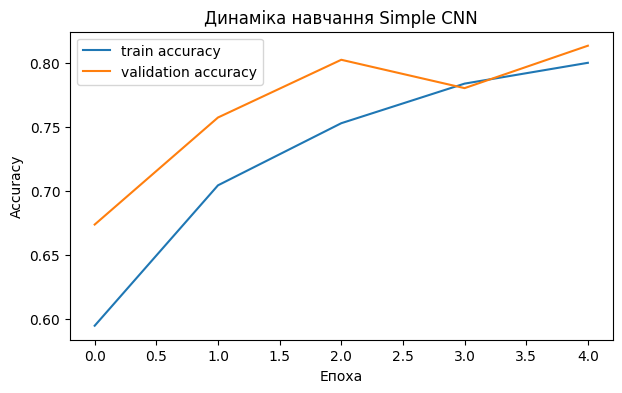

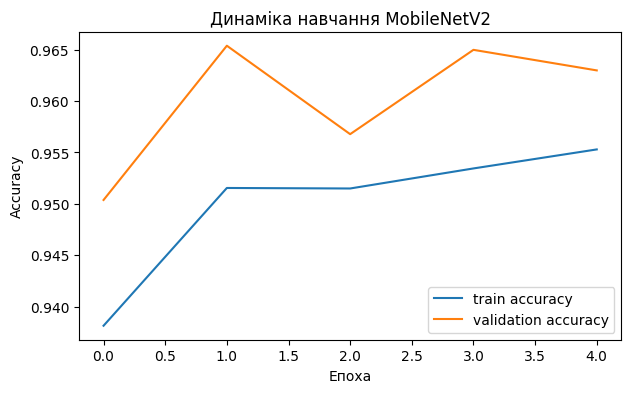

In [ ]:
def plot_learning_curves(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='validation accuracy')
    plt.title(title)
    plt.xlabel('Епоха')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_learning_curves(history_cnn, 'Динаміка навчання Simple CNN')
plot_learning_curves(history_mobilenet, 'Динаміка навчання MobileNetV2')


### Інтерпретація графіків навчання

Графіки accuracy для тренувальної та валідаційної вибірок допомагають оцінити, чи модель навчається стабільно. Якщо тренувальна accuracy зростає, а валідаційна також поступово зростає або залишається близькою, це означає, що модель добре узагальнює дані.

Якщо тренувальна accuracy значно вища за валідаційну, це може свідчити про перенавчання. У такому випадку модель занадто добре запам'ятовує навчальні приклади, але гірше працює на нових даних. Для зменшення перенавчання можна використовувати Dropout, аугментацію, EarlyStopping або зменшити складність моделі.


### Висновки щодо моделей

У роботі порівнюються дві моделі: проста CNN і MobileNetV2. Основним критерієм вибору фінальної моделі є F1-score, тому що ця метрика враховує баланс між precision та recall. Якщо модель має високу accuracy, але низький recall або precision, це означає, що вона може працювати нестабільно для одного з класів.

Якщо MobileNetV2 показує вищі accuracy та F1-score, її доцільно обрати як фінальну модель. Це логічно, тому що вона використовує попередньо навчені ознаки зображень і не починає навчання повністю з нуля. Такий підхід особливо корисний, коли навчання обмежене невеликою кількістю епох.

Якщо проста CNN має нижчий результат, це не означає, що вона побудована неправильно. Вона просто має складніше завдання: самостійно навчитися виділяти ознаки котів і собак лише з цього датасету. Для покращення простої CNN можна збільшити кількість епох, змінити архітектуру, додати регуляризацію або використати більший розмір зображення.

Confusion matrix дозволяє побачити, який клас модель плутає частіше. Якщо помилки розподілені приблизно рівномірно, модель працює збалансовано. Якщо ж один клас має значно більше помилок, потрібно додатково перевірити якість даних цього класу, можливий дисбаланс або налаштування порогу класифікації.


## 6. Збереження найкращої моделі

Після порівняння результатів зберігається модель, яка отримала найкращий F1-score на валідаційній вибірці. Збереження моделі потрібне для того, щоб її можна було повторно використати без нового навчання.

Формат .keras є зручним для збереження архітектури моделі, її ваг і налаштувань компіляції. Надалі цю модель можна завантажити і використати для прогнозування нових зображень.


In [ ]:
best_model.save('best_cat_dog_model.keras')
print(f"Збережено модель: {best_results['model']}")


Збережено модель: MobileNetV2


## 7. Тестування на власному зображенні

Після навчання модель перевіряється на власному зображенні, яке користувач завантажує у Colab. Перед прогнозом зображення проходить таку саму підготовку, як і навчальні дані: змінюється розмір до **128×128**, перетворюється на масив і нормалізується діленням на 255.

Важливо, щоб розмір зображення під час тестування збігався з розміром, який використовувався під час навчання. Якщо модель навчалася на зображеннях 128×128, а для прогнозу подати 160×160, може виникнути помилка або некоректна робота. Ця проблема виправлена через використання target_size=IMG_SIZE.

Оскільки на виході моделі використовується sigmoid, результат є числом від 0 до 1. Якщо значення більше або дорівнює 0.5, зображення класифікується як собака. Якщо значення менше 0.5, воно класифікується як кіт.


Saving Hmong_Bobtail_2-734x1024.jpg to Hmong_Bobtail_2-734x1024.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


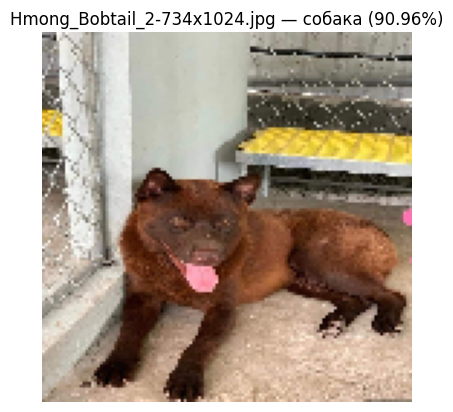

In [ ]:
uploaded = files.upload()

for fn in uploaded.keys():
    path = '/content/' + fn
    img = image.load_img(path, target_size=IMG_SIZE)
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    probability = float(best_model.predict(x)[0][0])

    plt.imshow(img)
    plt.axis('off')
    if probability >= 0.5:
        plt.title(f'{fn} — собака ({probability * 100:.2f}%)')
    else:
        plt.title(f'{fn} — кіт ({(1 - probability) * 100:.2f}%)')
    plt.show()


## Загальний підсумок

Виконано повний цикл роботи з задачею класифікації зображень котів і собак. Спочатку дані були завантажені та очищені від пошкоджених файлів. Далі проведено EDA: перевірено розподіл класів, побудовано візуалізації, розраховано описову статистику розмірів зображень, виявлено потенційні аномалії та переглянуто приклади зображень.

Для моделювання було побудовано дві моделі: просту CNN і MobileNetV2 з transfer learning. Це відповідає вимозі порівняння мінімум двох алгоритмів. Проста CNN використовується як базова модель, а MobileNetV2 як сильніший підхід на основі попередньо навчених ознак.

Якість моделей оцінюється за accuracy, precision, recall, F1-score, classification report і confusion matrix. Це дозволяє не лише визначити, яка модель працює краще загалом, а й зрозуміти, які саме класи вона плутає. Фінальна модель обирається за F1-score, оскільки ця метрика краще показує баланс якості класифікації.
